C:\Users\Administrator\AppData\Local\Temp\ipykernel_12628\1499329120.py:166: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


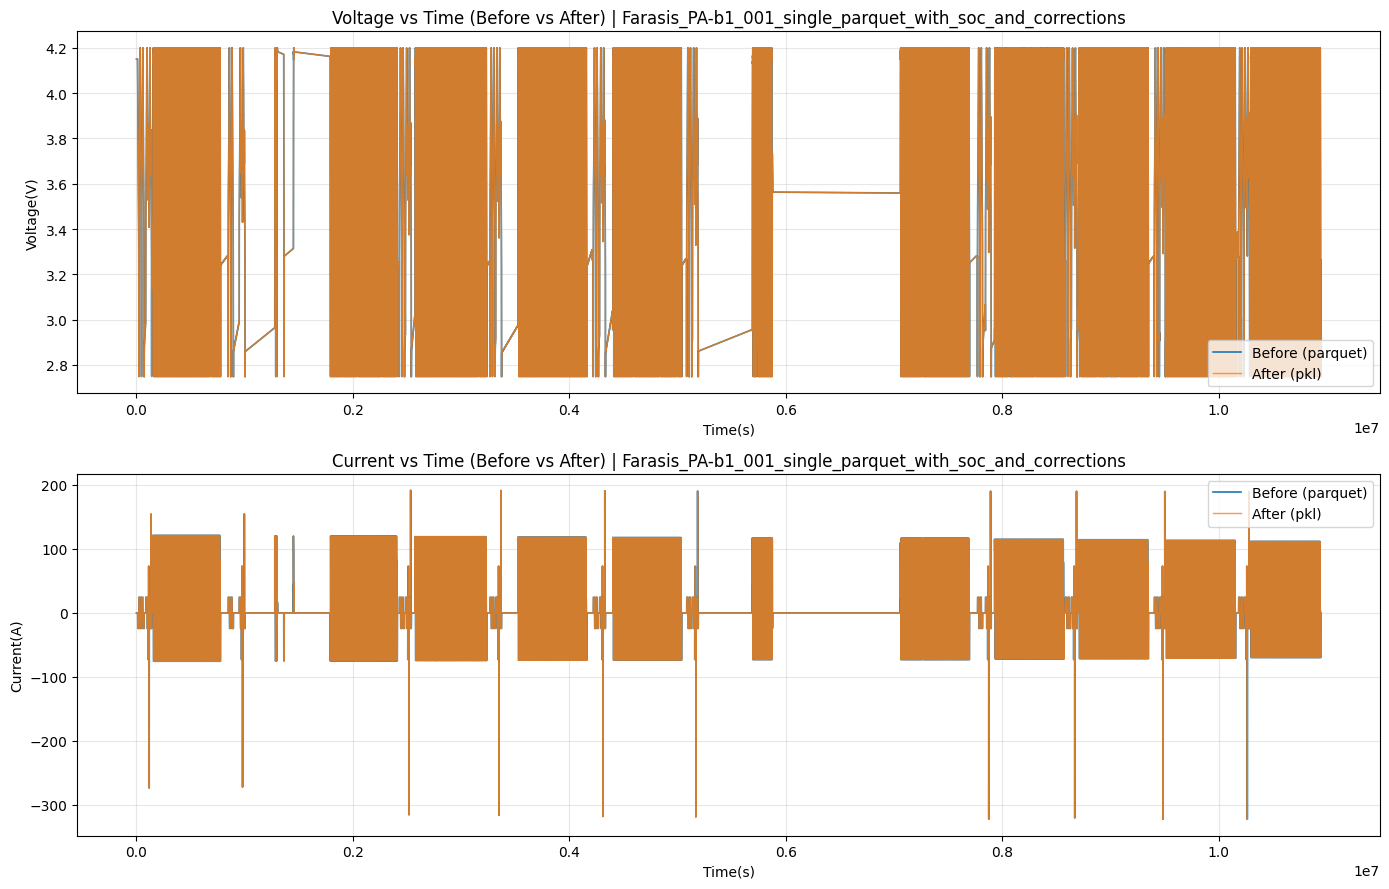

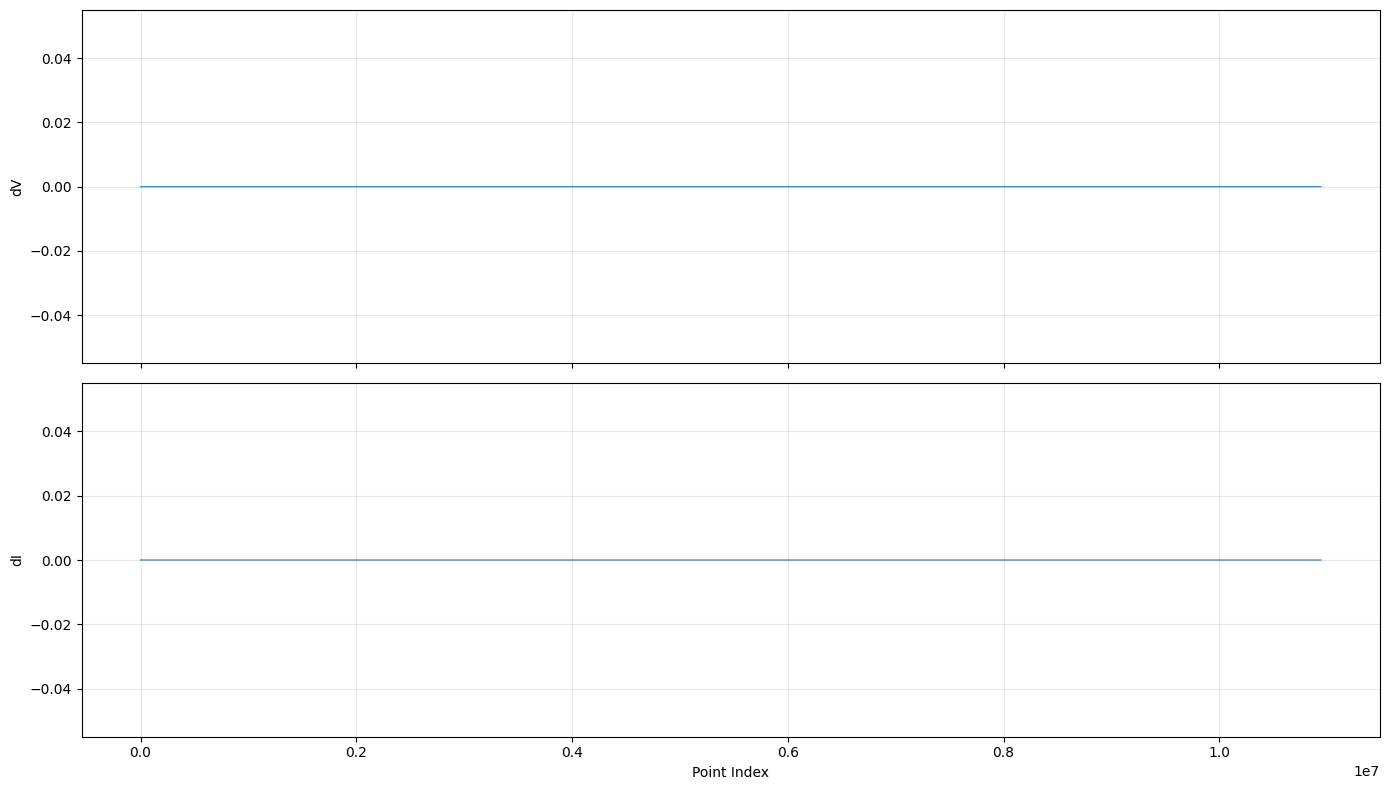

[1/3] OK   Farasis_PA-b1_001_single_parquet_with_soc_and_corrections | max_dV=0, max_dI=0


C:\Users\Administrator\AppData\Local\Temp\ipykernel_12628\1499329120.py:166: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


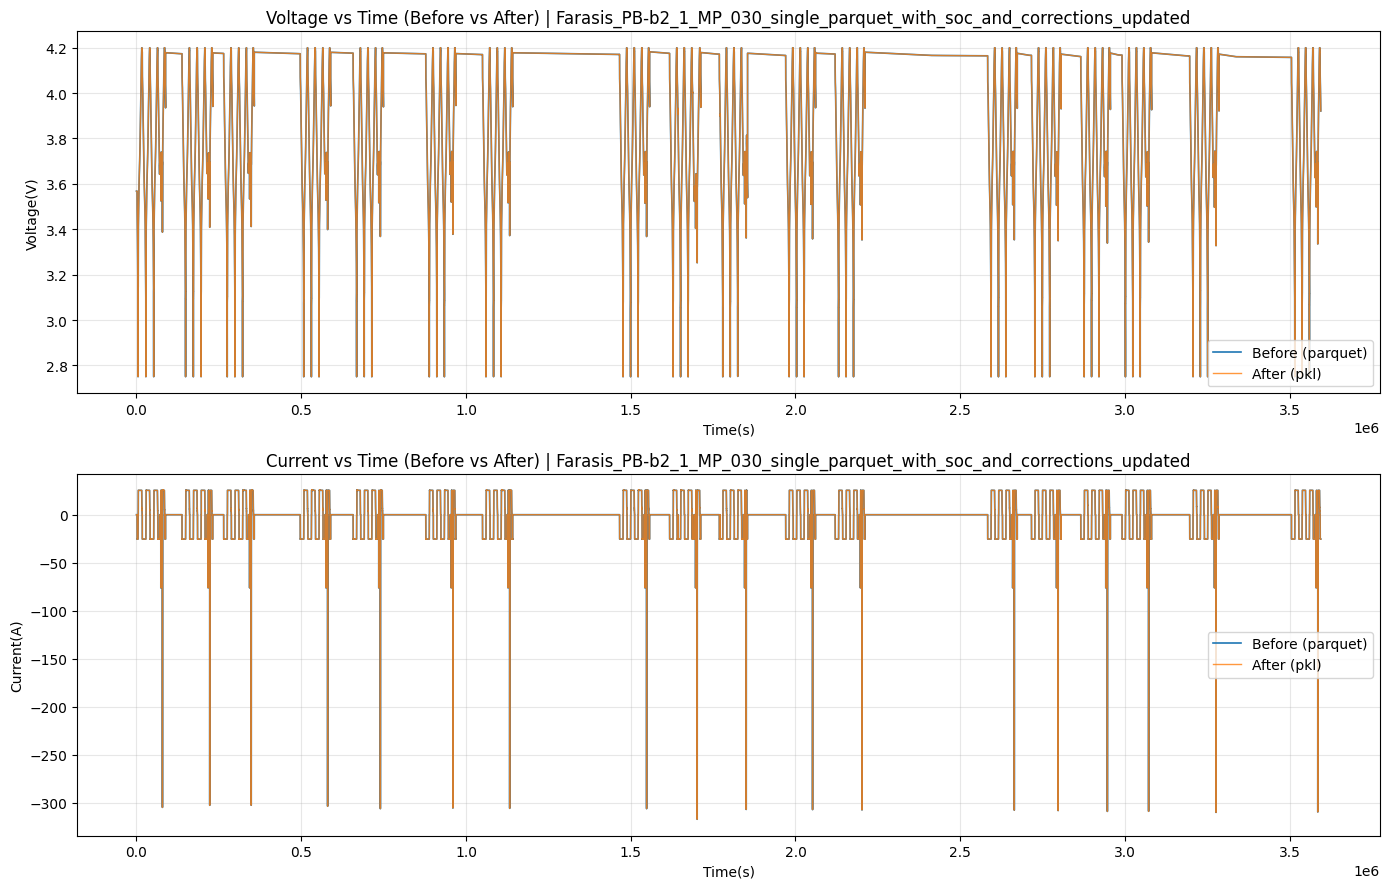

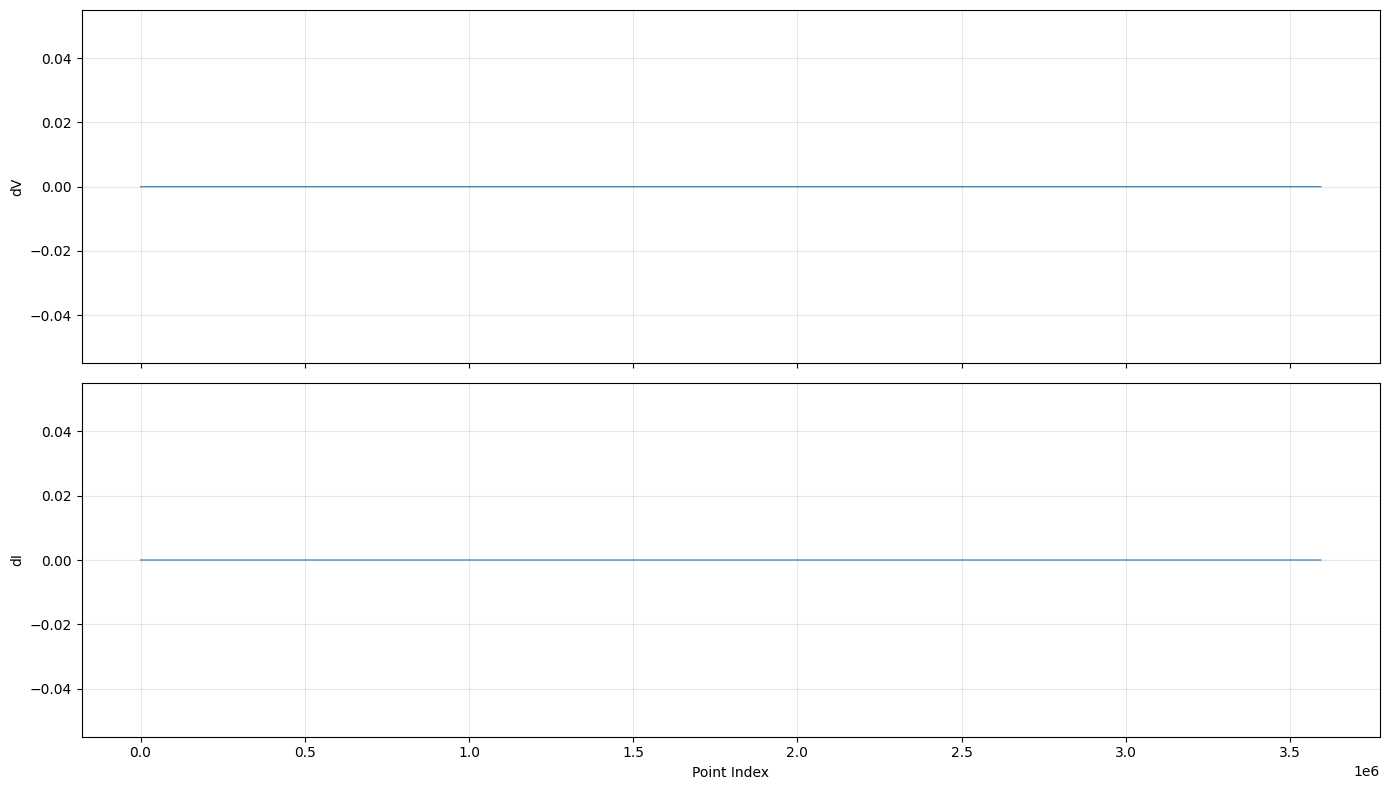

[2/3] OK   Farasis_PB-b2_1_MP_030_single_parquet_with_soc_and_corrections_updated | max_dV=0, max_dI=0


C:\Users\Administrator\AppData\Local\Temp\ipykernel_12628\1499329120.py:166: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


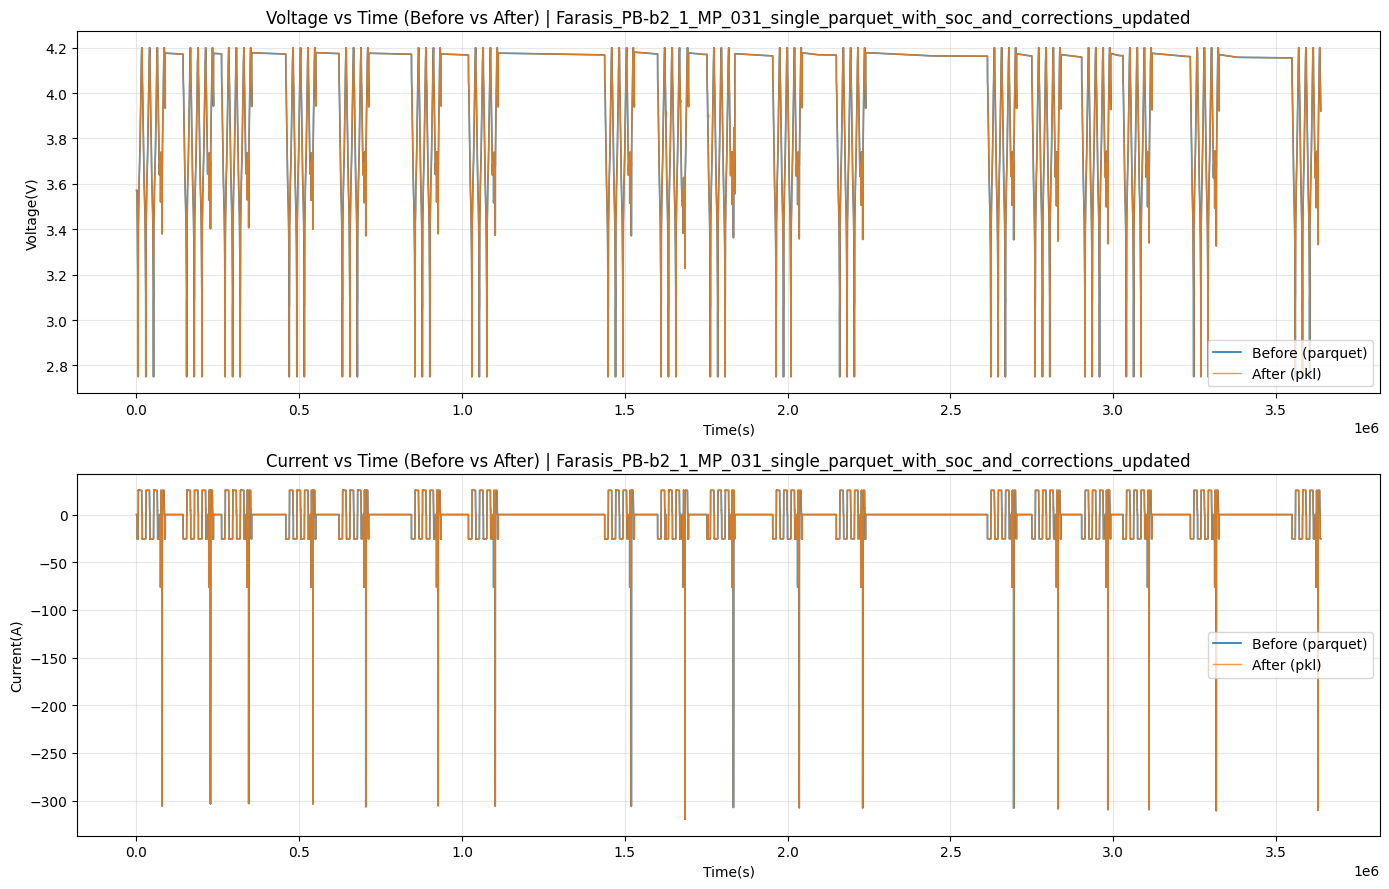

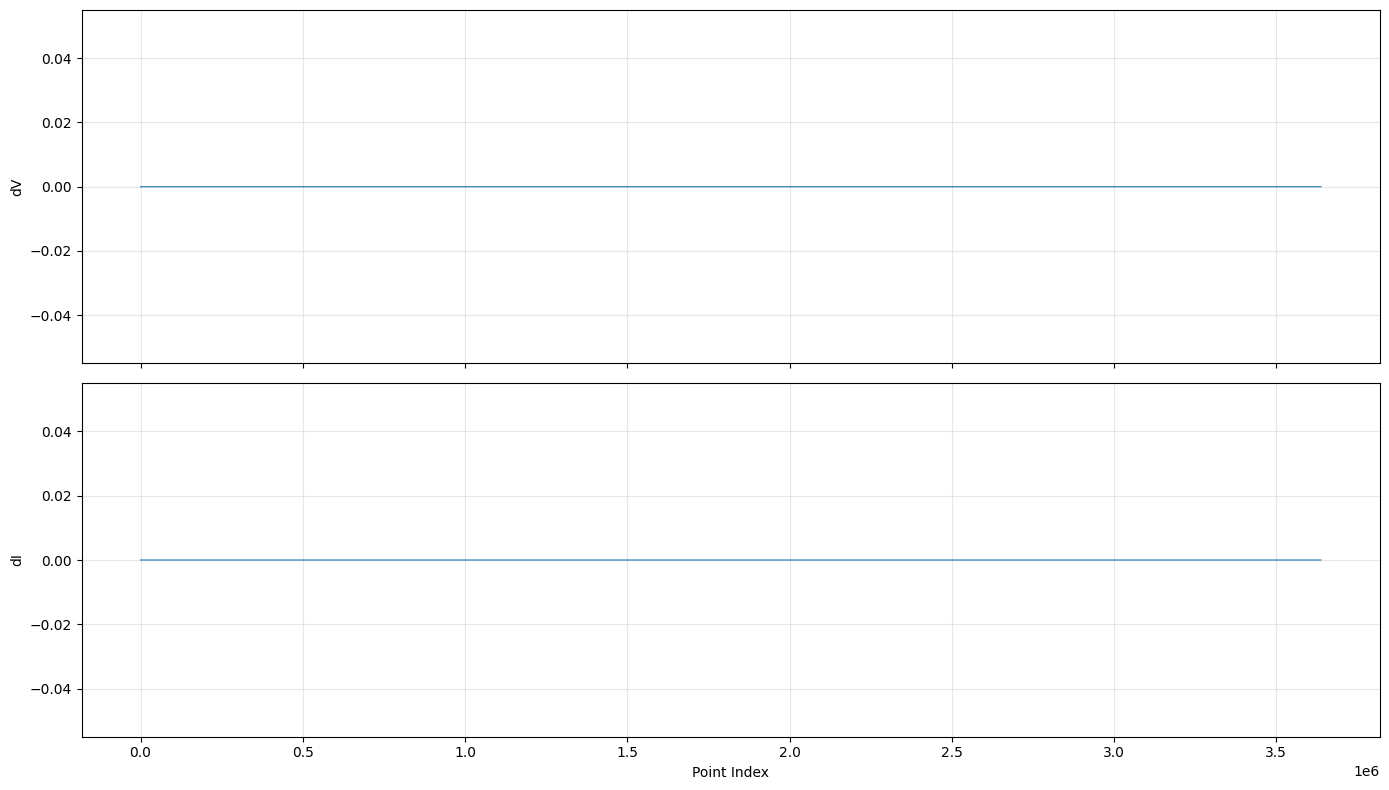

[3/3] OK   Farasis_PB-b2_1_MP_031_single_parquet_with_soc_and_corrections_updated | max_dV=0, max_dI=0

Done
total_selected=3
ok=3
missing_parquet=0
failed=0


In [1]:
from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for p in [start, *start.parents]:
        if (p / "dataset").exists() and (p / "check_data_scripts").exists():
            return p
    raise FileNotFoundError("Cannot locate project root containing dataset/ and check_data_scripts/")


def _build_time_in_seconds(df: pd.DataFrame) -> np.ndarray:
    if "time_stamp" in df.columns:
        ts = pd.to_datetime(df["time_stamp"], errors="coerce")
        if ts.notna().sum() >= 2:
            seconds = (ts - ts.iloc[0]).dt.total_seconds().to_numpy(dtype=float)
            return np.maximum.accumulate(np.nan_to_num(seconds, nan=0.0))

    if "del_time" in df.columns:
        dt = pd.to_numeric(df["del_time"], errors="coerce").fillna(0.0).to_numpy(dtype=float)
        dt = np.maximum(dt, 0.0)
        return np.cumsum(dt)

    return np.arange(len(df), dtype=float)


def _infer_segments_by_rpt_rule(df: pd.DataFrame):
    if "rpt" not in df.columns:
        return [(0, len(df))] if len(df) > 0 else []

    rpt_raw = pd.to_numeric(df["rpt"], errors="coerce").to_numpy(dtype=float)
    is_blank = ~np.isfinite(rpt_raw)

    segments = []
    n = len(df)
    start = 0
    while start < n:
        if is_blank[start]:
            end = start + 1
            while end < n and is_blank[end]:
                end += 1
            segments.append((start, end))
            start = end
        else:
            rv = rpt_raw[start]
            end = start + 1
            while end < n and (not is_blank[end]) and float(rpt_raw[end]) == float(rv):
                end += 1
            segments.append((start, end))
            start = end

    return segments


def extract_before_from_parquet(parquet_path: Path, first_n_cycles: int = 20):
    cols = ["current (A)", "voltage (V)", "time_stamp", "del_time", "rpt"]
    df = pd.read_parquet(parquet_path, columns=cols).copy()

    current = pd.to_numeric(df["current (A)"], errors="coerce")
    voltage = pd.to_numeric(df["voltage (V)"], errors="coerce")
    time_abs = _build_time_in_seconds(df)

    valid = np.isfinite(current.to_numpy(dtype=float)) & np.isfinite(voltage.to_numpy(dtype=float)) & np.isfinite(time_abs)
    df = df.loc[valid].reset_index(drop=True)

    current = current.loc[valid].to_numpy(dtype=float)
    voltage = voltage.loc[valid].to_numpy(dtype=float)
    time_abs = time_abs[valid]

    segments = _infer_segments_by_rpt_rule(df)
    segments = segments[:first_n_cycles]

    t_list, i_list, v_list = [], [], []
    offset = 0.0
    for s, e in segments:
        seg_t = time_abs[s:e]
        seg_i = current[s:e]
        seg_v = voltage[s:e]
        if len(seg_t) < 2:
            continue
        seg_t = seg_t - float(seg_t[0]) + offset
        offset = float(seg_t[-1])
        t_list.append(seg_t)
        i_list.append(seg_i)
        v_list.append(seg_v)

    if len(t_list) == 0:
        return np.array([]), np.array([]), np.array([])

    return np.concatenate(t_list), np.concatenate(i_list), np.concatenate(v_list)


def extract_after_from_pkl(pkl_path: Path, first_n_cycles: int = 20):
    with pkl_path.open("rb") as f:
        obj = pickle.load(f)

    cycle_data = obj.get("cycle_data", [])[:first_n_cycles]
    t_list, i_list, v_list = [], [], []

    for cyc in cycle_data:
        t = np.asarray(cyc.get("time_in_s", []), dtype=float)
        i = np.asarray(cyc.get("current_in_A", []), dtype=float)
        v = np.asarray(cyc.get("voltage_in_V", []), dtype=float)
        if len(t) < 2:
            continue
        t_list.append(t)
        i_list.append(i)
        v_list.append(v)

    if len(t_list) == 0:
        return np.array([]), np.array([]), np.array([])

    t = np.concatenate(t_list)
    t = t - float(t[0])
    return t, np.concatenate(i_list), np.concatenate(v_list)


def compare_before_after(parquet_path: Path, pkl_path: Path, first_n_cycles: int = 20):
    bt, bi, bv = extract_before_from_parquet(parquet_path, first_n_cycles=first_n_cycles)
    at, ai, av = extract_after_from_pkl(pkl_path, first_n_cycles=first_n_cycles)

    n = min(len(bt), len(at))
    if n == 0:
        raise ValueError("No valid points found for comparison.")

    bt, bi, bv = bt[:n], bi[:n], bv[:n]
    at, ai, av = at[:n], ai[:n], av[:n]

    dv = bv - av
    di = bi - ai

    report = {
        "points_before": int(len(bt)),
        "points_after": int(len(at)),
        "same_length": bool(len(bt) == len(at)),
        "voltage_exact_equal": bool(np.array_equal(bv, av)),
        "current_exact_equal": bool(np.array_equal(bi, ai)),
        "voltage_allclose_1e-6": bool(np.allclose(bv, av, atol=1e-6, rtol=1e-6)),
        "current_allclose_1e-6": bool(np.allclose(bi, ai, atol=1e-6, rtol=1e-6)),
        "max_abs_err_voltage": float(np.max(np.abs(dv))),
        "max_abs_err_current": float(np.max(np.abs(di))),
    }

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=False)
    ax1.plot(bt, bv, label="Before (parquet)", linewidth=1.2)
    ax1.plot(at, av, label="After (pkl)", linewidth=1.0, alpha=0.8)
    ax1.set_title(f"Voltage vs Time (Before vs After) | {pkl_path.stem}")
    ax1.set_xlabel("Time(s)")
    ax1.set_ylabel("Voltage(V)")
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.plot(bt, bi, label="Before (parquet)", linewidth=1.2)
    ax2.plot(at, ai, label="After (pkl)", linewidth=1.0, alpha=0.8)
    ax2.set_title(f"Current vs Time (Before vs After) | {pkl_path.stem}")
    ax2.set_xlabel("Time(s)")
    ax2.set_ylabel("Current(A)")
    ax2.legend()
    ax2.grid(alpha=0.3)

    fig.tight_layout()
    plt.show()
    plt.close(fig)

    fig2, (bx1, bx2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    idx = np.arange(n)
    bx1.plot(idx, dv, linewidth=0.8)
    bx1.set_ylabel("dV")
    bx1.grid(alpha=0.3)

    bx2.plot(idx, di, linewidth=0.8)
    bx2.set_ylabel("dI")
    bx2.set_xlabel("Point Index")
    bx2.grid(alpha=0.3)

    fig2.tight_layout()
    plt.show()
    plt.close(fig2)

    return report


repo_root = _find_repo_root(Path.cwd())
raw_root = repo_root / "dataset" / "raw" / "Farasis"
pkl_dir = repo_root / "dataset" / "processed" / "Farasis"

# 构建 parquet 映射：Farasis_<raw相对路径去后缀并下划线拼接> -> parquet 文件
parquet_map = {}
for pq in raw_root.rglob("*.parquet"):
    rel_no_suffix = pq.relative_to(raw_root).with_suffix("")
    key = f"Farasis_{'_'.join(rel_no_suffix.parts)}"
    parquet_map[key] = pq

# 遍历全部 Farasis pkl（不截断）
pkl_files = sorted([p for p in pkl_dir.glob("Farasis_*.pkl")])
if len(pkl_files) == 0:
    raise FileNotFoundError(f"No Farasis pkl files found under: {pkl_dir}")

ok = 0
missing_parquet = 0
failed = 0

for i, pkl_path in enumerate(pkl_files, start=1):
    stem = pkl_path.stem
    parquet_path = parquet_map.get(stem)
    if parquet_path is None:
        missing_parquet += 1
        print(f"[{i}/{len(pkl_files)}] SKIP missing parquet: {stem}")
        continue

    try:
        report = compare_before_after(parquet_path, pkl_path, first_n_cycles=20)
        ok += 1
        print(f"[{i}/{len(pkl_files)}] OK   {stem} | max_dV={report['max_abs_err_voltage']:.6g}, max_dI={report['max_abs_err_current']:.6g}")
    except Exception as e:
        failed += 1
        print(f"[{i}/{len(pkl_files)}] FAIL {stem} -> {type(e).__name__}: {e}")

print("\nDone")
print(f"total_selected={len(pkl_files)}")
print(f"ok={ok}")
print(f"missing_parquet={missing_parquet}")
print(f"failed={failed}")